In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
!wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv


--2026-10-05 22:32:01--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv.2’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.01s   

2026-10-05 22:32:01 (53.3 MB/s) - ‘car_fuel_efficiency_2026.csv.2’ saved [635180/635180]



# Q.1)

In [3]:
columns = [
    'engine_displacement', 
    'horsepower', 
    'vehicle_weight', 
    'model_year', 
    'fuel_efficiency_mpg'
]
df = pd.read_csv('car_fuel_efficiency_2026.csv', usecols=columns)

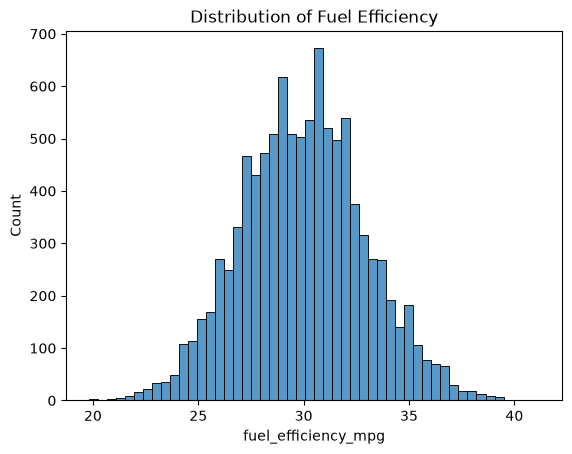

In [4]:
sns.histplot(df['fuel_efficiency_mpg'], bins=50)
plt.title('Distribution of Fuel Efficiency')
plt.show()

In [5]:
df.isnull().sum()

model_year               0
engine_displacement      0
horsepower             877
vehicle_weight           0
fuel_efficiency_mpg      0
dtype: int64

In [6]:
# The answer is horsepower

# Q.2) 

In [7]:
df['horsepower'].median()

np.float64(254.0)

In [8]:
# The answer is 254

# Q.3)

In [9]:
# Code instructed to use for shuffling and splitting the dataset

# Also, missing column is horsepower

In [10]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [11]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

df_train = df_train.drop(columns=['fuel_efficiency_mpg'])
df_val = df_val.drop(columns=['fuel_efficiency_mpg'])
df_test = df_test.drop(columns=['fuel_efficiency_mpg'])

In [12]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [13]:
missing_col = 'horsepower' # Update this from Q1

# Option 1: Fill with 0
X_train_0 = df_train.fillna(0).values
X_val_0 = df_val.fillna(0).values

w0_0, w_0 = train_linear_regression(X_train_0, y_train)
y_pred_0 = w0_0 + X_val_0.dot(w_0)
rmse_0 = rmse(y_val, y_pred_0)

# Option 2: Fill with the mean (computed from training data only)
mean_val = df_train[missing_col].mean()
X_train_mean = df_train.fillna(mean_val).values
X_val_mean = df_val.fillna(mean_val).values

w0_mean, w_mean = train_linear_regression(X_train_mean, y_train)
y_pred_mean = w0_mean + X_val_mean.dot(w_mean)
rmse_mean = rmse(y_val, y_pred_mean)

# Print and compare the results rounded to 3 decimal digits
print("RMSE when filling with 0:", round(rmse_0, 3))
print("RMSE when filling with mean:", round(rmse_mean, 3))

RMSE when filling with 0: 2.205
RMSE when filling with mean: 2.202


In [14]:
# The answer is filling with mean. Why? a lower Root Mean Squared Error (RMSE) means
# that the model's predictions are closer to the actual values

# Q.4)

In [15]:
# Define the regularized linear regression function from the lectures
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    
    # Add regularization to the main diagonal
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

# Ensure datasets are filled with 0
X_train_0 = df_train.fillna(0).values
X_val_0 = df_val.fillna(0).values

# Test the different values of r
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]

for r in r_values:
    w0, w = train_linear_regression_reg(X_train_0, y_train, r=r)
    y_pred = w0 + X_val_0.dot(w)
    score = rmse(y_val, y_pred)
    
    # Round the RMSE score to 4 decimal digits
    print(f"r: {r:>5} | RMSE: {round(score, 4)}")

r:     0 | RMSE: 2.2053
r:  0.01 | RMSE: 2.2058
r:   0.1 | RMSE: 2.2241
r:     1 | RMSE: 2.3492
r:     5 | RMSE: 2.4094
r:    10 | RMSE: 2.4195
r:   100 | RMSE: 2.4292


In [16]:
# The answer is 0

# Q.5)

In [17]:
# Define the seeds to iterate over
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmse_scores = []

for seed in seeds:
    # 1. Prepare the split
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].copy()
    df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
    
    # 2. Separate the target variable
    y_train = df_train['fuel_efficiency_mpg'].values
    y_val = df_val['fuel_efficiency_mpg'].values

    # Drop the target from the training and validation datasets
    df_train = df_train.drop(columns=['fuel_efficiency_mpg'])
    df_val = df_val.drop(columns=['fuel_efficiency_mpg'])
    
    # 3. Fill missing values with 0
    X_train_0 = df_train.fillna(0).values
    X_val_0 = df_val.fillna(0).values
    
    # 4. Train the model without regularization (using the function from Q3)
    w0, w = train_linear_regression(X_train_0, y_train)
    
    # 5. Evaluate and collect the RMSE score
    y_pred = w0 + X_val_0.dot(w)
    score = rmse(y_val, y_pred)
    rmse_scores.append(score)

# Compute the standard deviation of all collected scores
std_scores = np.std(rmse_scores)

# Print the result rounded to 3 decimal digits
print(f"Standard deviation: {round(std_scores, 3)}")

Standard deviation: 0.029


In [18]:
# The standard deviation is 0.029

# Q.6)

In [19]:
# 1. Split the dataset, use seed 9
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]].copy()
df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
df_test = df.iloc[idx[n_train + n_val:]].copy()

# 2. Combine train and validation datasets
df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# Separate the target variable
y_full_train = df_full_train['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

# Drop the target from the features
df_full_train = df_full_train.drop(columns=['fuel_efficiency_mpg'])
df_test = df_test.drop(columns=['fuel_efficiency_mpg'])

# 3. Fill missing values with 0 and train a model with r=0.001
X_full_train_0 = df_full_train.fillna(0).values
X_test_0 = df_test.fillna(0).values

# Use the regularized function defined in Question 4
w0, w = train_linear_regression_reg(X_full_train_0, y_full_train, r=0.001)

# 4. dataset's RMSE
y_pred_test = w0 + X_test_0.dot(w)
score = rmse(y_test, y_pred_test)

print(f"RMSE on test dataset: {round(score, 3)}")

RMSE on test dataset: 2.236


In [20]:
# The answer is 2.236